# 03. Exploratory Data Analysis

## PART 1: Count Data

This notebook is used for the exploratory data anlysis of the processed count dataset before fitting the first-stage model for normal cycling counts.

We inspect variable types, categorical variable frequencies, continuous variable distributions, and the distribution of the modelling outcome.

The outcome for the first modelling stage is the 2-hour cyclist count. The variable `count_rescaled` is used as the modelling outcome because it represents the adjusted 2-hour count after handling mostly complete intervals with some missing 15-minute observations.

### Importing packages, establishing path and reading count data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
project_folder = Path("..")

processed_folder = project_folder / "data" / "processed"
diagnostics_folder = project_folder / "outputs" / "diagnostics"

diagnostics_folder.mkdir(parents=True, exist_ok=True)

In [3]:
counts_model_final = pd.read_csv(
    processed_folder / "counts_model_final.csv"
)

counts_model_final.head()

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,...,site_name,municipality,district,installation_date,direction_description,is_public_holiday,holiday_name,is_school_holiday,school_holiday_name,fuel_price_petrol_95
0,1,IN,2022,2022-05-01,5,Sunday,0,13.0,8,8,...,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
1,1,IN,2022,2022-05-01,5,Sunday,2,2.0,8,8,...,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
2,1,IN,2022,2022-05-01,5,Sunday,4,1.0,8,8,...,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
3,1,IN,2022,2022-05-01,5,Sunday,6,6.0,8,8,...,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
4,1,IN,2022,2022-05-01,5,Sunday,8,26.0,8,8,...,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153


### Structure of the dataset

In [4]:
print("Rows:", counts_model_final.shape[0])
print("Columns:", counts_model_final.shape[1])

Rows: 4587736
Columns: 27


In [5]:
counts_model_final.dtypes

site_id                         int64
direction                         str
year                            int64
date                              str
month                           int64
weekday                           str
hour_bin                        int64
count                         float64
observed_intervals              int64
total_intervals                 int64
missing_intervals               int64
missing_share                 float64
expected_intervals_for_row      int64
count_rescaled                  int64
rescaled                        int64
longitude                     float64
latitude                      float64
site_name                         str
municipality                      str
district                          str
installation_date                 str
direction_description             str
is_public_holiday               int64
holiday_name                      str
is_school_holiday               int64
school_holiday_name               str
fuel_price_p

In [6]:
pd.set_option("display.max_columns", None)
counts_model_final.head()

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,missing_intervals,missing_share,expected_intervals_for_row,count_rescaled,rescaled,longitude,latitude,site_name,municipality,district,installation_date,direction_description,is_public_holiday,holiday_name,is_school_holiday,school_holiday_name,fuel_price_petrol_95
0,1,IN,2022,2022-05-01,5,Sunday,0,13.0,8,8,0,0.0,8,13,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
1,1,IN,2022,2022-05-01,5,Sunday,2,2.0,8,8,0,0.0,8,2,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
2,1,IN,2022,2022-05-01,5,Sunday,4,1.0,8,8,0,0.0,8,1,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
3,1,IN,2022,2022-05-01,5,Sunday,6,6.0,8,8,0,0.0,8,6,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
4,1,IN,2022,2022-05-01,5,Sunday,8,26.0,8,8,0,0.0,8,26,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153


In [7]:
pd.set_option("display.max_columns", None)
counts_model_final.tail()

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,missing_intervals,missing_share,expected_intervals_for_row,count_rescaled,rescaled,longitude,latitude,site_name,municipality,district,installation_date,direction_description,is_public_holiday,holiday_name,is_school_holiday,school_holiday_name,fuel_price_petrol_95
4587731,152,OUT,2026,2026-04-30,4,Thursday,14,102.0,8,8,0,0.0,8,102,0,4.149169,50.968901,Opwijk,District Vilvoorde-gewestwegen,Opwijk,2025-10-31,Opwijk Fietser rich Aalst,0,No public holiday,0,No school holiday,1.82212
4587732,152,OUT,2026,2026-04-30,4,Thursday,16,82.0,8,8,0,0.0,8,82,0,4.149169,50.968901,Opwijk,District Vilvoorde-gewestwegen,Opwijk,2025-10-31,Opwijk Fietser rich Aalst,0,No public holiday,0,No school holiday,1.82212
4587733,152,OUT,2026,2026-04-30,4,Thursday,18,27.0,8,8,0,0.0,8,27,0,4.149169,50.968901,Opwijk,District Vilvoorde-gewestwegen,Opwijk,2025-10-31,Opwijk Fietser rich Aalst,0,No public holiday,0,No school holiday,1.82212
4587734,152,OUT,2026,2026-04-30,4,Thursday,20,17.0,8,8,0,0.0,8,17,0,4.149169,50.968901,Opwijk,District Vilvoorde-gewestwegen,Opwijk,2025-10-31,Opwijk Fietser rich Aalst,0,No public holiday,0,No school holiday,1.82212
4587735,152,OUT,2026,2026-04-30,4,Thursday,22,4.0,8,8,0,0.0,8,4,0,4.149169,50.968901,Opwijk,District Vilvoorde-gewestwegen,Opwijk,2025-10-31,Opwijk Fietser rich Aalst,0,No public holiday,0,No school holiday,1.82212


Converting date variable into date format variable

In [8]:
date_columns = [
    "date",
    "installation_date",
]

for column in date_columns:
    if column in counts_model_final.columns:
        counts_model_final[column] = pd.to_datetime(
            counts_model_final[column],
            errors="coerce"
        )

### Defining variable groups

In [9]:
outcome_variable = "count_rescaled"

categorical_variables = [
    "site_id",
    "direction",
    "year",
    "month",
    "weekday",
    "hour_bin",
    "municipality",
    "district",
    "is_public_holiday",
    "holiday_name",
    "is_school_holiday",
    "school_holiday_name",
]

continuous_variables = [
    "fuel_price_petrol_95",
]

In [10]:
categorical_variables = [
    variable for variable in categorical_variables
    if variable in counts_model_final.columns
]

continuous_variables = [
    variable for variable in continuous_variables
    if variable in counts_model_final.columns
]

In [11]:
print("Categorical variables:")
print(categorical_variables)

print("\nContinuous variables:")
print(continuous_variables)

Categorical variables:
['site_id', 'direction', 'year', 'month', 'weekday', 'hour_bin', 'municipality', 'district', 'is_public_holiday', 'holiday_name', 'is_school_holiday', 'school_holiday_name']

Continuous variables:
['fuel_price_petrol_95']


### Outcome varaible distribution

In [12]:
counts_model_final[outcome_variable].describe()

count    4.587736e+06
mean     2.135951e+01
std      4.899166e+01
min      0.000000e+00
25%      0.000000e+00
50%      4.000000e+00
75%      2.100000e+01
max      8.682000e+03
Name: count_rescaled, dtype: float64

In [13]:
print("Minimum count:", counts_model_final[outcome_variable].min())
print("Maximum count:", counts_model_final[outcome_variable].max())
print("Mean count:", counts_model_final[outcome_variable].mean())
print("Median count:", counts_model_final[outcome_variable].median())
print("Share of zero counts:", (counts_model_final[outcome_variable] == 0).mean())

Minimum count: 0
Maximum count: 8682
Mean count: 21.359510442623552
Median count: 4.0
Share of zero counts: 0.2734843504508542


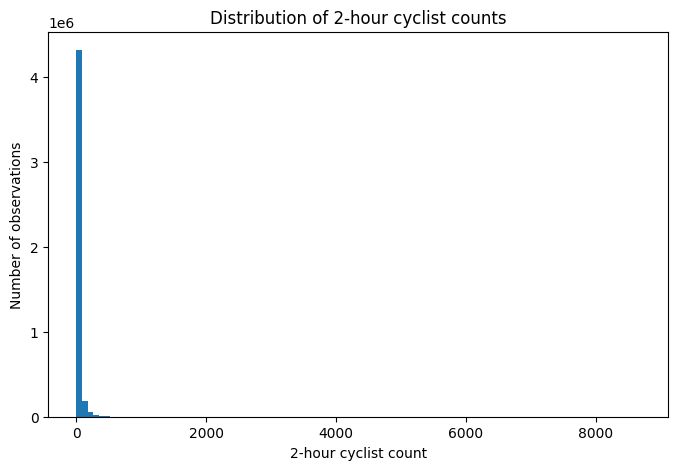

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(counts_model_final[outcome_variable], bins=100)
plt.title("Distribution of 2-hour cyclist counts")
plt.xlabel("2-hour cyclist count")
plt.ylabel("Number of observations")
plt.show()

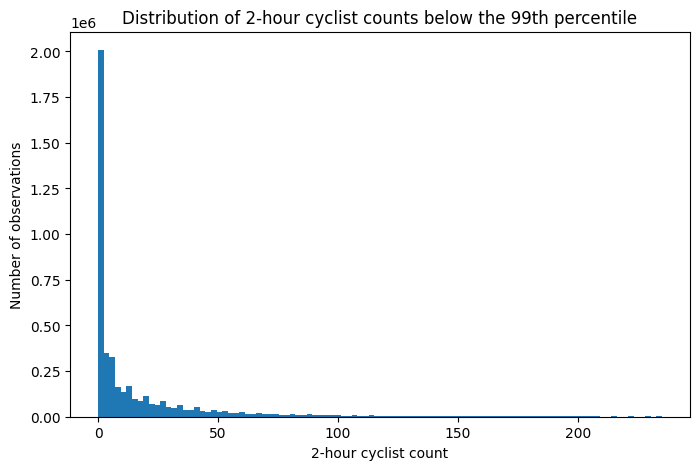

In [15]:
upper_limit = counts_model_final[outcome_variable].quantile(0.99)

plt.figure(figsize=(8, 5))
plt.hist(
    counts_model_final.loc[
        counts_model_final[outcome_variable] <= upper_limit,
        outcome_variable
    ],
    bins=100
)
plt.title("Distribution of 2-hour cyclist counts below the 99th percentile")
plt.xlabel("2-hour cyclist count")
plt.ylabel("Number of observations")
plt.show()

In [16]:
zero_summary = (
    counts_model_final
    .assign(is_zero_count=(counts_model_final[outcome_variable] == 0).astype(int))
    .groupby(["year", "month"])
    .agg(
        observations=(outcome_variable, "size"),
        zero_counts=("is_zero_count", "sum"),
        zero_share=("is_zero_count", "mean"),
    )
    .reset_index()
)

zero_summary

,year,month,observations,zero_counts,zero_share
0,2022,5,34796,8563,0.246092
1,2022,6,45336,11503,0.253728
2,2022,7,64382,15657,0.243189
3,2022,8,79314,19365,0.244156
4,2022,9,81064,22279,0.274832
5,2022,10,92264,24689,0.267591
6,2022,11,92544,27494,0.297091
7,2022,12,95202,32288,0.339153
8,2023,1,95414,31585,0.331031
9,2023,2,88074,26006,0.295274


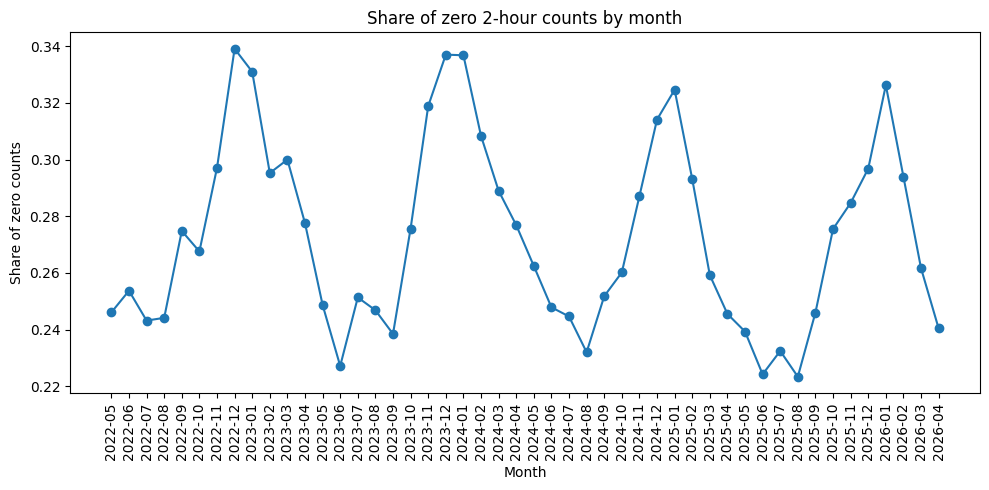

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(
    zero_summary["year"].astype(str) + "-" + zero_summary["month"].astype(str).str.zfill(2),
    zero_summary["zero_share"],
    marker="o"
)
plt.xticks(rotation=90)
plt.title("Share of zero 2-hour counts by month")
plt.xlabel("Month")
plt.ylabel("Share of zero counts")
plt.tight_layout()
plt.show()

**Overdispersion**

In [18]:
outcome_mean = counts_model_final[outcome_variable].mean()
outcome_variance = counts_model_final[outcome_variable].var()

print("Mean:", outcome_mean)
print("Variance:", outcome_variance)
print("Variance-to-mean ratio:", outcome_variance / outcome_mean)

Mean: 21.359510442623552
Variance: 2400.1831423144695
Variance-to-mean ratio: 112.37070010391395


In [19]:
dispersion_by_site = (
    counts_model_final
    .groupby("site_id")
    .agg(
        mean_count=(outcome_variable, "mean"),
        variance_count=(outcome_variable, "var"),
        observations=(outcome_variable, "size"),
    )
    .reset_index()
)

dispersion_by_site["variance_to_mean_ratio"] = (
    dispersion_by_site["variance_count"] / dispersion_by_site["mean_count"]
)

dispersion_by_site = dispersion_by_site.sort_values(
    "variance_to_mean_ratio",
    ascending=False
)

pd.set_option("display.max_rows", None)
dispersion_by_site

,site_id,mean_count,variance_count,observations,variance_to_mean_ratio
139,142,190.502033,45653.920647,984,239.650570
63,64,90.386941,21648.763665,33832,239.512073
121,122,30.921305,7166.346077,31298,231.760791
138,140,82.188405,14118.410204,26236,171.781046
135,137,83.315190,13331.610296,26162,160.014162
140,143,182.752530,28653.644463,21150,156.789318
136,138,79.513472,12370.479685,26574,155.577154
106,107,185.158676,27107.596276,32330,146.401977
124,125,66.898187,9708.180155,30890,145.118733
65,66,43.862980,5794.399132,33652,132.102268


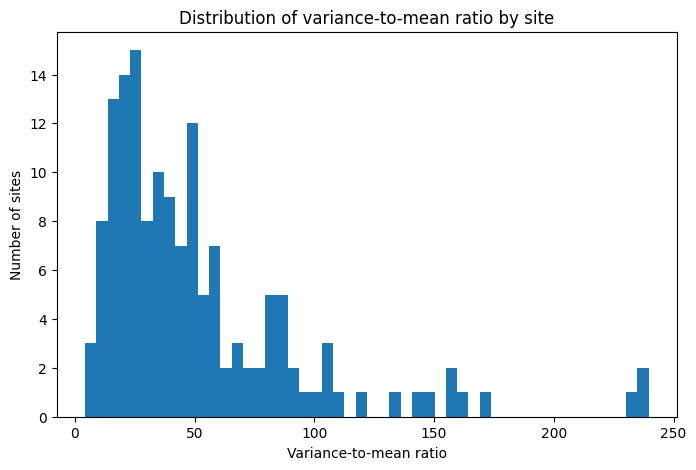

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(
    dispersion_by_site["variance_to_mean_ratio"].replace([float("inf")], pd.NA).dropna(),
    bins=50
)
plt.title("Distribution of variance-to-mean ratio by site")
plt.xlabel("Variance-to-mean ratio")
plt.ylabel("Number of sites")
plt.show()

### Categorical predictors

In [21]:
def categorical_count_table(data, variable):
    table = (
        data[variable]
        .value_counts(dropna=False)
        .reset_index()
    )

    table.columns = [variable, "count"]
    table["percentage"] = 100 * table["count"] / len(data)

    return table

In [22]:
for variable in categorical_variables:
    print("\n" + "=" * 80)
    print(variable)
    display(categorical_count_table(counts_model_final, variable).head(30))


site_id


,site_id,count,percentage
0,2,35056,0.764124
1,4,35056,0.764124
2,5,35056,0.764124
3,8,35056,0.764124
4,9,35056,0.764124
5,10,35056,0.764124
6,11,35056,0.764124
7,13,35056,0.764124
8,14,35056,0.764124
9,15,35056,0.764124



direction


,direction,count,percentage
0,IN,2293874,50.000131
1,OUT,2293862,49.999869



year


...

,holiday_name,count,percentage
0,No public holiday,4414804,96.230559
1,Good Friday,13200,0.287724
2,Easter Monday,13152,0.286677
3,All Saints' Day,13080,0.285108
4,Armistice Day,13080,0.285108
5,Christmas Day,12960,0.282492
6,St. Stephen's Day,12960,0.282492
7,New Year's Day,12954,0.282361
8,Easter Sunday,12902,0.281228
9,Assumption Day,12364,0.269501



is_school_holiday


,is_school_holiday,count,percentage
0,0,3281386,71.525171
1,1,1306350,28.474829



school_holiday_name


,school_holiday_name,count,percentage
0,No school holiday,3281386,71.525171
1,Summer Holidays,753754,16.429760
2,Spring Holidays,187858,4.094787
3,Winter Holidays,181352,3.952974
4,Carnival Holidays,91934,2.003908
5,All Saints Holidays,91452,1.993402


### Continuous predictors

In [23]:
counts_model_final[continuous_variables].describe().T

,count,mean,std,min,25%,50%,75%,max
fuel_price_petrol_95,4587736.0,1.65791,0.116624,1.4482,1.55825,1.64865,1.71891,2.11083


In [24]:
def plot_histogram(data, variable, bins=50):
    plt.figure(figsize=(8, 5))
    plt.hist(data[variable].dropna(), bins=bins)
    plt.title(f"Distribution of {variable}")
    plt.xlabel(variable)
    plt.ylabel("Number of observations")
    plt.tight_layout()
    plt.show()

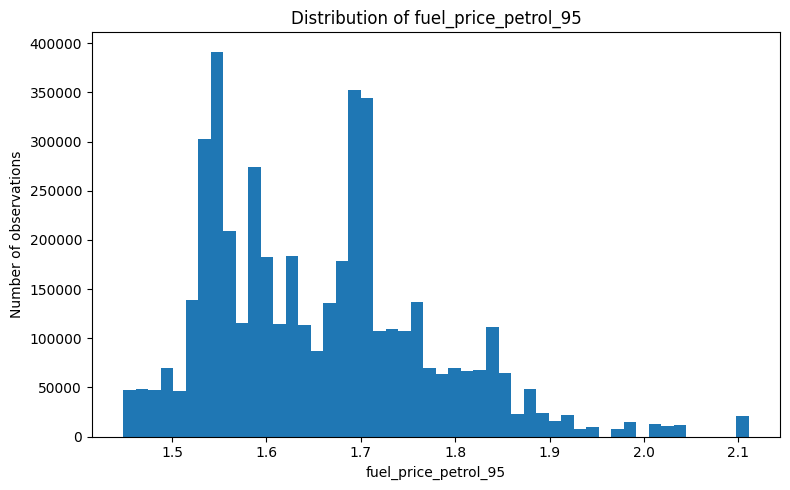

In [25]:
for variable in continuous_variables:
    plot_histogram(counts_model_final, variable)

## PART 2: Deviations Data

### Load data

In [26]:
prediction_data = pd.read_csv(
    processed_folder / "prediction_data_with_factors.csv",
    dtype={
        'outdoor_music_event_type': str,
        'indoor_music_event_type': str,
        'sport_event_type': str
    }
)

prediction_data.head()

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,missing_intervals,missing_share,expected_intervals_for_row,count_rescaled,rescaled,longitude,latitude,site_name,municipality,district,installation_date,direction_description,is_public_holiday,holiday_name,is_school_holiday,school_holiday_name,fuel_price_petrol_95,coord_combo,geopy_municipality,geopy_province,geopy_region,temperature_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_mean,precipitation_category,is_strike,is_outdoor_music,outdoor_music_event_type,is_indoor_music,indoor_music_event_type,is_sport_event,sport_event_type
0,1,IN,2025,2025-05-01,5,Thursday,0,1.0,8,8,0,0.0,8,1.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,15.00,0.0,0.0,0.0,5.95,dry,0,0,NaN,0,NaN,0,NaN
1,1,IN,2025,2025-05-01,5,Thursday,2,1.0,8,8,0,0.0,8,1.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,13.05,0.0,0.0,0.0,5.80,dry,0,0,NaN,0,NaN,0,NaN
2,1,IN,2025,2025-05-01,5,Thursday,4,3.0,8,8,0,0.0,8,3.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,11.20,0.0,0.0,0.0,5.10,dry,0,0,NaN,0,NaN,0,NaN
3,1,IN,2025,2025-05-01,5,Thursday,6,3.0,8,8,0,0.0,8,3.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,10.50,0.0,0.0,0.0,5.95,dry,0,0,NaN,0,NaN,0,NaN
4,1,IN,2025,2025-05-01,5,Thursday,8,43.0,8,8,0,0.0,8,43.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,14.55,0.0,0.0,0.0,6.00,dry,0,0,NaN,0,NaN,0,NaN


### Validation and structural check

In [27]:
print(f"Total Rows: {prediction_data.shape[0]}")
print(f"Total Columns: {prediction_data.shape[1]}")

Total Rows: 1177575
Total Columns: 44


In [28]:
prediction_data.dtypes

site_id                         int64
direction                         str
year                            int64
date                              str
month                           int64
weekday                           str
hour_bin                        int64
count                         float64
observed_intervals              int64
total_intervals                 int64
missing_intervals               int64
missing_share                 float64
expected_intervals_for_row      int64
count_rescaled                float64
rescaled                        int64
longitude                     float64
latitude                      float64
site_name                         str
municipality                      str
district                          str
installation_date                 str
direction_description             str
is_public_holiday               int64
holiday_name                      str
is_school_holiday               int64
school_holiday_name               str
fuel_price_p

In [29]:
pd.set_option("display.max_columns", None)
prediction_data.head()

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,missing_intervals,missing_share,expected_intervals_for_row,count_rescaled,rescaled,longitude,latitude,site_name,municipality,district,installation_date,direction_description,is_public_holiday,holiday_name,is_school_holiday,school_holiday_name,fuel_price_petrol_95,coord_combo,geopy_municipality,geopy_province,geopy_region,temperature_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_mean,precipitation_category,is_strike,is_outdoor_music,outdoor_music_event_type,is_indoor_music,indoor_music_event_type,is_sport_event,sport_event_type
0,1,IN,2025,2025-05-01,5,Thursday,0,1.0,8,8,0,0.0,8,1.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,15.00,0.0,0.0,0.0,5.95,dry,0,0,NaN,0,NaN,0,NaN
1,1,IN,2025,2025-05-01,5,Thursday,2,1.0,8,8,0,0.0,8,1.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,13.05,0.0,0.0,0.0,5.80,dry,0,0,NaN,0,NaN,0,NaN
2,1,IN,2025,2025-05-01,5,Thursday,4,3.0,8,8,0,0.0,8,3.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,11.20,0.0,0.0,0.0,5.10,dry,0,0,NaN,0,NaN,0,NaN
3,1,IN,2025,2025-05-01,5,Thursday,6,3.0,8,8,0,0.0,8,3.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,10.50,0.0,0.0,0.0,5.95,dry,0,0,NaN,0,NaN,0,NaN
4,1,IN,2025,2025-05-01,5,Thursday,8,43.0,8,8,0,0.0,8,43.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,14.55,0.0,0.0,0.0,6.00,dry,0,0,NaN,0,NaN,0,NaN


In [30]:
pd.set_option("display.max_columns", None)
prediction_data.tail()

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,missing_intervals,missing_share,expected_intervals_for_row,count_rescaled,rescaled,longitude,latitude,site_name,municipality,district,installation_date,direction_description,is_public_holiday,holiday_name,is_school_holiday,school_holiday_name,fuel_price_petrol_95,coord_combo,geopy_municipality,geopy_province,geopy_region,temperature_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_mean,precipitation_category,is_strike,is_outdoor_music,outdoor_music_event_type,is_indoor_music,indoor_music_event_type,is_sport_event,sport_event_type
1177570,143,OUT,2026,2026-04-30,4,Thursday,14,385.0,8,8,0,0.0,8,385.0,0,3.26286,50.83066,Eco Display Classic Budastraat,Kortrijk,NaN,2023-12-08,YTH17062596 Cyclists OUT,0,No public holiday,0,No school holiday,1.82212,"50.83066, 3.26286",Kortrijk,West Flanders,Flanders,19.80,0.0,0.0,0.0,19.00,dry,0,0,NaN,0,NaN,0,NaN
1177571,143,OUT,2026,2026-04-30,4,Thursday,16,860.0,8,8,0,0.0,8,860.0,0,3.26286,50.83066,Eco Display Classic Budastraat,Kortrijk,NaN,2023-12-08,YTH17062596 Cyclists OUT,0,No public holiday,0,No school holiday,1.82212,"50.83066, 3.26286",Kortrijk,West Flanders,Flanders,20.45,0.0,0.0,0.0,19.25,dry,0,0,NaN,0,NaN,0,NaN
1177572,143,OUT,2026,2026-04-30,4,Thursday,18,394.0,8,8,0,0.0,8,394.0,0,3.26286,50.83066,Eco Display Classic Budastraat,Kortrijk,NaN,2023-12-08,YTH17062596 Cyclists OUT,0,No public holiday,0,No school holiday,1.82212,"50.83066, 3.26286",Kortrijk,West Flanders,Flanders,20.35,0.0,0.0,0.0,19.20,dry,0,0,NaN,0,NaN,0,NaN
1177573,143,OUT,2026,2026-04-30,4,Thursday,20,193.0,8,8,0,0.0,8,193.0,0,3.26286,50.83066,Eco Display Classic Budastraat,Kortrijk,NaN,2023-12-08,YTH17062596 Cyclists OUT,0,No public holiday,0,No school holiday,1.82212,"50.83066, 3.26286",Kortrijk,West Flanders,Flanders,18.70,0.0,0.0,0.0,15.15,dry,0,0,NaN,0,NaN,0,NaN
1177574,143,OUT,2026,2026-04-30,4,Thursday,22,144.0,8,8,0,0.0,8,144.0,0,3.26286,50.83066,Eco Display Classic Budastraat,Kortrijk,NaN,2023-12-08,YTH17062596 Cyclists OUT,0,No public holiday,0,No school holiday,1.82212,"50.83066, 3.26286",Kortrijk,West Flanders,Flanders,16.10,0.0,0.0,0.0,15.40,dry,0,0,NaN,0,NaN,0,NaN


In [31]:
date_columns = [
    "date",
    "installation_date"
]

for column in date_columns:
    if column in prediction_data.columns:
        prediction_data[column] = pd.to_datetime(
           prediction_data[column],
            errors="coerce"
        )

### Missing data check (Mostly for rechecking new-created columns)

In [32]:
prediction_data.isna().sum()

site_id                             0
direction                           0
year                                0
date                                0
month                               0
weekday                             0
hour_bin                            0
count                               0
observed_intervals                  0
total_intervals                     0
missing_intervals                   0
missing_share                       0
expected_intervals_for_row          0
count_rescaled                      0
rescaled                            0
longitude                           0
latitude                            0
site_name                           0
municipality                        0
district                         6562
installation_date                   0
direction_description               0
is_public_holiday                   0
holiday_name                        0
is_school_holiday                   0
school_holiday_name                 0
fuel_price_p

Reloading the dataset from csv file makes the "No event" values automatically become missing values. I recoded them below. 

In [33]:
event_type_columns = [
    'outdoor_music_event_type', 
    'indoor_music_event_type', 
    'sport_event_type'
]

for col in event_type_columns:
    if col in prediction_data.columns:
        prediction_data[col] = prediction_data[col].fillna("No event")

In [34]:
prediction_data.isna().sum()

site_id                          0
direction                        0
year                             0
date                             0
month                            0
weekday                          0
hour_bin                         0
count                            0
observed_intervals               0
total_intervals                  0
missing_intervals                0
missing_share                    0
expected_intervals_for_row       0
count_rescaled                   0
rescaled                         0
longitude                        0
latitude                         0
site_name                        0
municipality                     0
district                      6562
installation_date                0
direction_description            0
is_public_holiday                0
holiday_name                     0
is_school_holiday                0
school_holiday_name              0
fuel_price_petrol_95             0
coord_combo                      0
geopy_municipality  

### Defining variable groups

In [35]:
categorical_variables = [
    "weekday", "hour_bin", "month", 
    "geopy_region", "geopy_province", "geopy_municipality",
    "is_public_holiday", "holiday_name", "is_school_holiday", "school_holiday_name",
    "precipitation_category", # <-- NEW Weather category
    "is_strike", "is_outdoor_music", "outdoor_music_event_type",
    "is_indoor_music", "indoor_music_event_type", "is_sport_event", "sport_event_type"
]

continuous_variables = [
    "fuel_price_petrol_95",
    "temperature_mean",     
    "precipitation_sum", 
    "rain_sum", 
    "snowfall_sum", 
    "wind_speed_mean"
]

categorical_variables = [var for var in categorical_variables if var in prediction_data.columns]
continuous_variables = [var for var in continuous_variables if var in prediction_data.columns]

print(f"Tracking {len(categorical_variables)} Categorical Variables.")
print(f"Tracking {len(continuous_variables)} Continuous Variables.")

Tracking 18 Categorical Variables.
Tracking 6 Continuous Variables.


### Baseline Traffic Sanity Check

We don't use count_rescaled as our outcome variable anymore, I guess. But I will still conduct a brief check here to compare the distribution with the past data and consider it as a baseline.

In [36]:
prediction_data["count_rescaled"].describe()

count    1.177575e+06
mean     2.409010e+01
std      5.301451e+01
min      0.000000e+00
25%      0.000000e+00
50%      5.000000e+00
75%      2.500000e+01
max      4.740000e+03
Name: count_rescaled, dtype: float64

In [37]:
print("Minimum count:", prediction_data["count_rescaled"].min())
print("Maximum count:", prediction_data["count_rescaled"].max())
print("Mean count:", prediction_data["count_rescaled"].mean())
print("Median count:", prediction_data["count_rescaled"].median())
print("Share of zero counts:", (prediction_data["count_rescaled"] == 0).mean())

Minimum count: 0.0
Maximum count: 4740.0
Mean count: 24.090098841141447
Median count: 5.0
Share of zero counts: 0.25593104473175804


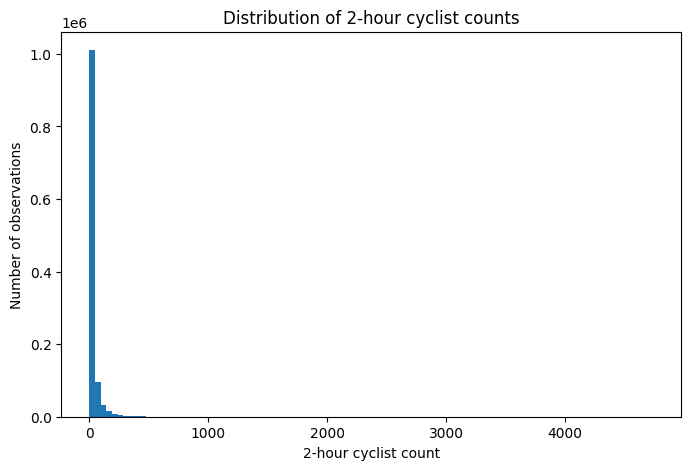

In [38]:
plt.figure(figsize=(8, 5))
plt.hist(prediction_data["count_rescaled"], bins=100)
plt.title("Distribution of 2-hour cyclist counts")
plt.xlabel("2-hour cyclist count")
plt.ylabel("Number of observations")
plt.show()

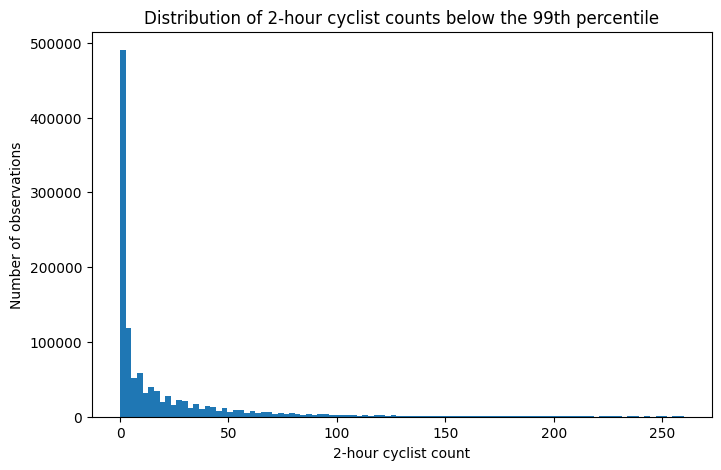

In [39]:
upper_limit = prediction_data["count_rescaled"].quantile(0.99)

plt.figure(figsize=(8, 5))
plt.hist(
    prediction_data.loc[
        prediction_data["count_rescaled"] <= upper_limit,
        "count_rescaled"
    ],
    bins=100
)
plt.title("Distribution of 2-hour cyclist counts below the 99th percentile")
plt.xlabel("2-hour cyclist count")
plt.ylabel("Number of observations")
plt.show()

### Categorical predictors

In [40]:
def categorical_count_table(data, variable):
    table = (
        data[variable]
        .value_counts(dropna=False)
        .reset_index()
    )

    table.columns = [variable, "count"]
    table["percentage"] = 100 * table["count"] / len(data)

    return table

In [41]:
for variable in categorical_variables:
    print("\n" + "=" * 80)
    print(variable)
    display(categorical_count_table(prediction_data, variable).head(30))


weekday


,weekday,count,percentage
0,Thursday,171006,14.521878
1,Monday,167848,14.253699
2,Saturday,167821,14.251406
3,Friday,167805,14.250048
4,Tuesday,167763,14.246481
5,Wednesday,167741,14.244613
6,Sunday,167591,14.231875



hour_bin


,hour_bin,count,percentage
0,14,98164,8.336114
1,12,98163,8.336030
2,18,98162,8.335945
3,20,98162,8.335945
4,10,98160,8.335775
5,22,98160,8.335775
6,16,98159,8.335690
7,6,98156,8.335435
8,8,98153,8.335180
9,0,98150,8.334926



month


...

,indoor_music_event_type,count,percentage
0,No event,1177287,99.975543
1,indoor concert,150,0.012738
2,indoor music festival,54,0.004586
3,indoor electronic concert,48,0.004076
4,indoor orchestral concert,24,0.002038
5,musical concert/show,12,0.001019



is_sport_event


,is_sport_event,count,percentage
0,0,1175971,99.863788
1,1,1604,0.136212



sport_event_type


,sport_event_type,count,percentage
0,No event,1175971,99.863788
1,cycling participation event,648,0.055028
2,cyclocross race,432,0.036686
3,road cycling race,264,0.022419
4,cyclocross world cup,120,0.010190
5,road cycling stage race,96,0.008152
6,running event,44,0.003736


### Continuous predictors

In [42]:
prediction_data[continuous_variables].describe().T

,count,mean,std,min,25%,50%,75%,max
fuel_price_petrol_95,1177575.0,1.569154,0.105046,1.4482,1.52342,1.54093,1.55825,1.8965
temperature_mean,1177575.0,12.085717,6.705686,-7.2000,7.30000,12.00000,16.65000,37.2000
precipitation_sum,1177575.0,0.149679,0.565626,0.0000,0.00000,0.00000,0.00000,19.6000
rain_sum,1177575.0,0.141433,0.546132,0.0000,0.00000,0.00000,0.00000,19.6000
snowfall_sum,1177575.0,0.005776,0.090623,0.0000,0.00000,0.00000,0.00000,10.7100
wind_speed_mean,1177575.0,12.601872,6.067722,0.1000,8.00000,11.85000,16.45000,51.4000


In [43]:
def plot_histogram(data, variable, bins=50):
    plt.figure(figsize=(8, 5))
    plt.hist(data[variable].dropna(), bins=bins)
    plt.title(f"Distribution of {variable}")
    plt.xlabel(variable)
    plt.ylabel("Number of observations")
    plt.tight_layout()
    plt.show()

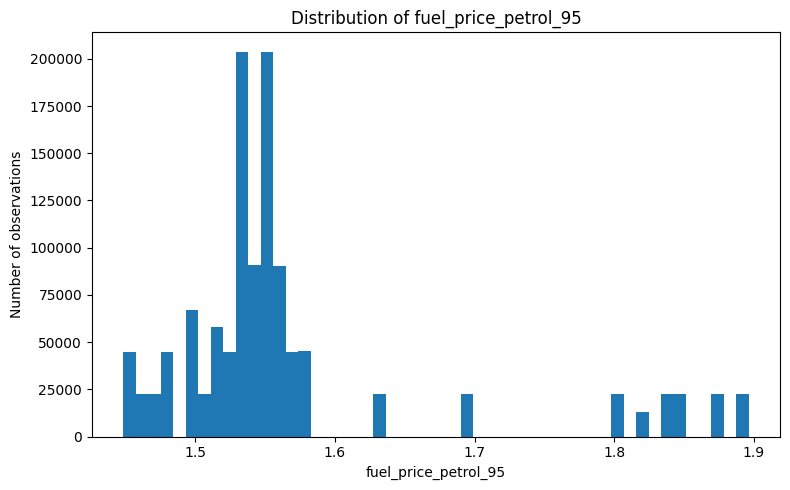

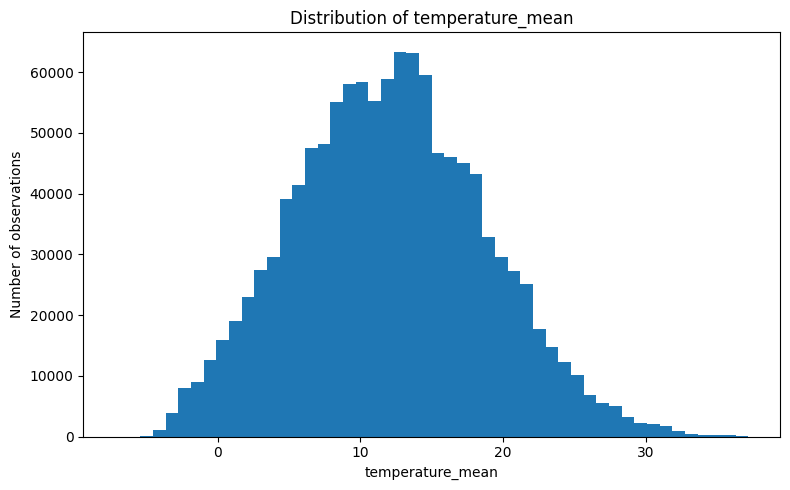

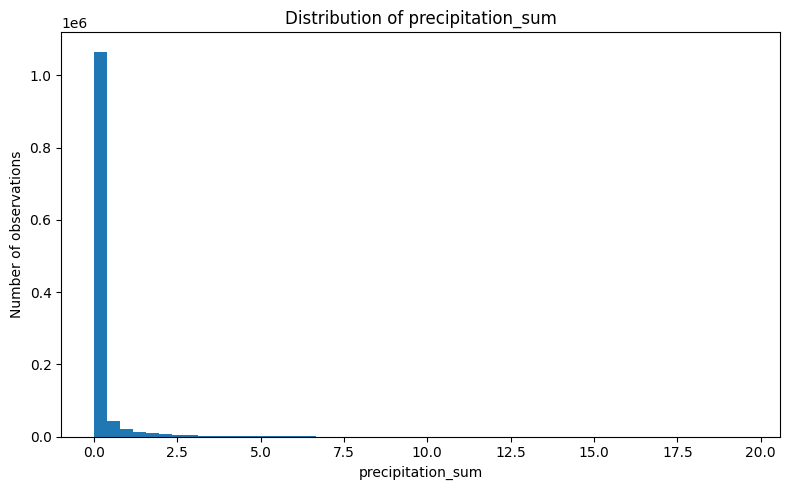

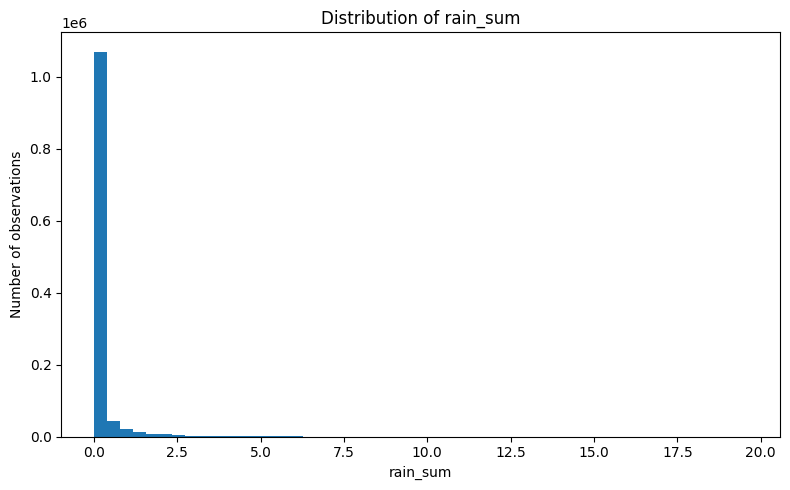

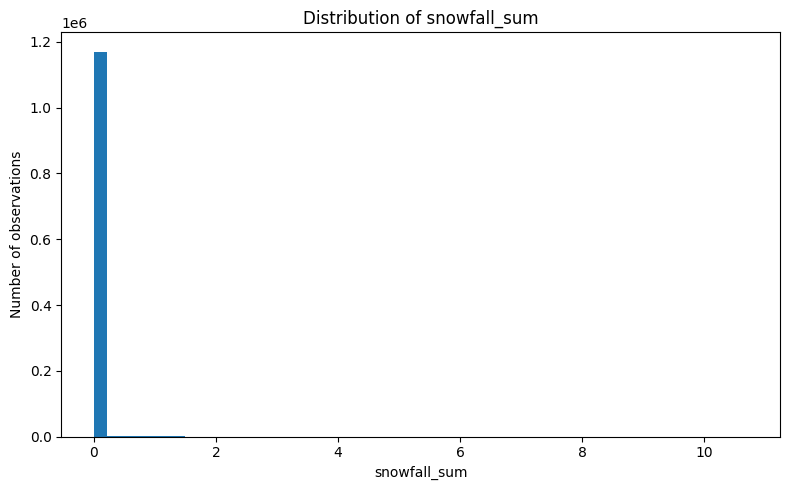

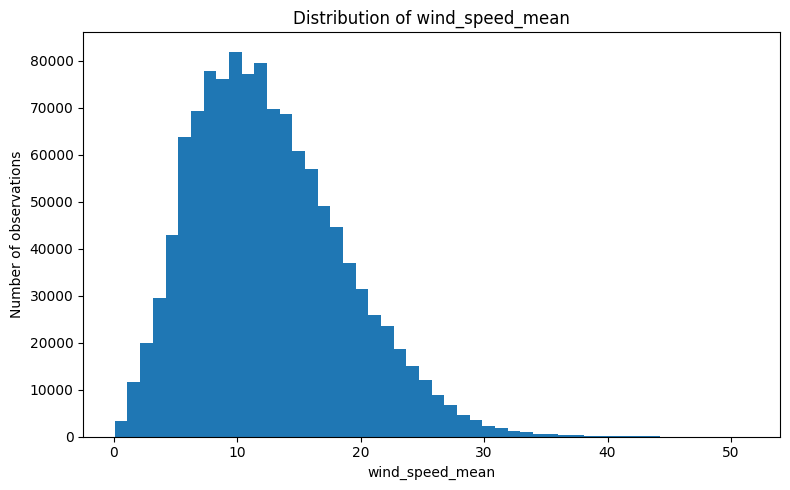

In [44]:
for variable in continuous_variables:
    plot_histogram(prediction_data, variable)

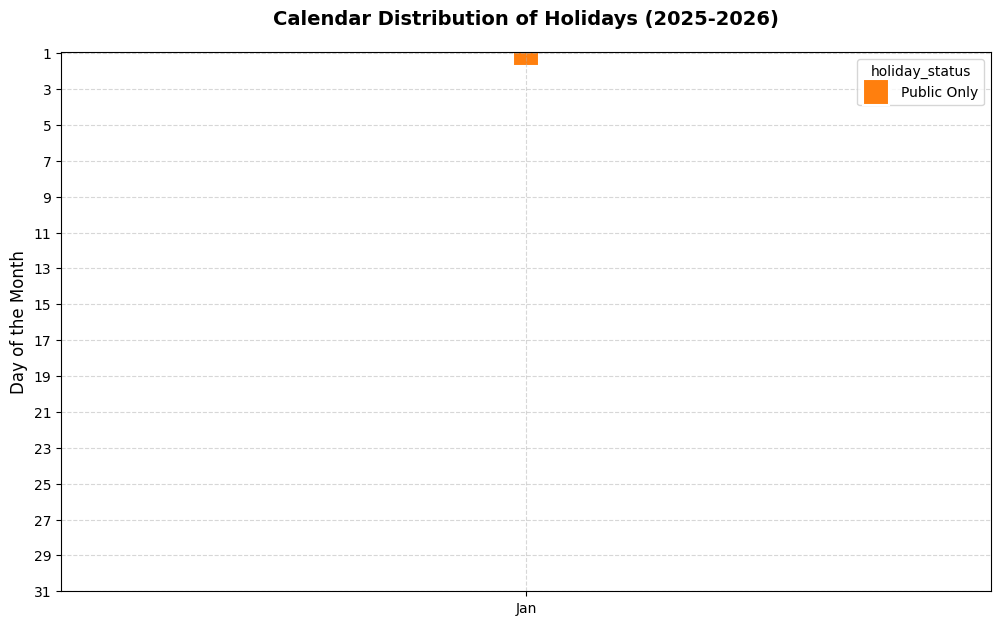

In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. PREPARE THE DATA
# ==========================================
# Create mutually exclusive categories so we don't double-count overlapping holidays
conditions = [
    (prediction_data['is_public_holiday'] == 1) & (prediction_data['is_school_holiday'] == 1),
    (prediction_data['is_public_holiday'] == 1) & (prediction_data['is_school_holiday'] == 0),
    (prediction_data['is_public_holiday'] == 0) & (prediction_data['is_school_holiday'] == 1),
    (prediction_data['is_public_holiday'] == 0) & (prediction_data['is_school_holiday'] == 0)
]
choices = ['Both (Public & School)', 'Public Only', 'School Only', 'Regular Day']
prediction_data['holiday_status'] = np.select(conditions, choices, default='Unknown')

# Aggregate the 2-hour interval data to a DAILY level
# We take the first 'holiday_status' of the day, since holidays apply to the whole day
daily_df = prediction_data.groupby(prediction_data['hour_bin']).agg({
    'holiday_status': 'first'
}).reset_index()

# Convert the grouped date back to a datetime object to extract Month and Day
daily_df['date'] = pd.to_datetime(daily_df['hour_bin'])

# Extract Month (abbreviated name, e.g., 'Jan') and Day (1-31)
daily_df['Month'] = daily_df['date'].dt.strftime('%b') 
daily_df['Month_Num'] = daily_df['date'].dt.month # Keep month number for proper chronological sorting
daily_df['Day'] = daily_df['date'].dt.day

# Sort the data so the X-axis plots Jan -> Dec in the correct order
daily_df = daily_df.sort_values(['Month_Num', 'Day'])

# Filter out normal days so the calendar grid only highlights the holidays
holidays_only = daily_df[daily_df['holiday_status'] != 'Regular Day']


# ==========================================
# 2. PLOT THE CALENDAR GRID
# ==========================================
# Set up a wide figure
fig, ax = plt.subplots(figsize=(12, 7))

# Draw the scatter plot using square markers ('s')
sns.scatterplot(
    data=holidays_only,
    x='Month',
    y='Day',
    hue='holiday_status',
    palette={
        'Both (Public & School)': '#d62728', # Red
        'Public Only': '#ff7f0e',            # Orange
        'School Only': '#1f77b4'             # Blue
    },
    marker='s',                              # 's' makes it a square
    s=350,                                   # Size of the square markers
    edgecolor='white',                       # Adds a tiny border to separate touching squares
    ax=ax
)

# ==========================================
# 3. FORMATTING (The Calendar Look)
# ==========================================
ax.set_title("Calendar Distribution of Holidays (2025-2026)", pad=20, fontsize=14, fontweight='bold')
ax.set_xlabel("")
ax.set_ylabel("Day of the Month", fontsize=12)

# INVERT Y-AXIS: Put Day 1 at the top, and Day 31 at the bottom (like a real calendar)
ax.invert_yaxis()

# Show every other day on the Y-axis for a cleaner look
ax.set_yticks(range(1, 32, 2))

# Add a light grid to mimic calendar boxes
ax.grid(True, linestyle='--', alpha=0.5)

#

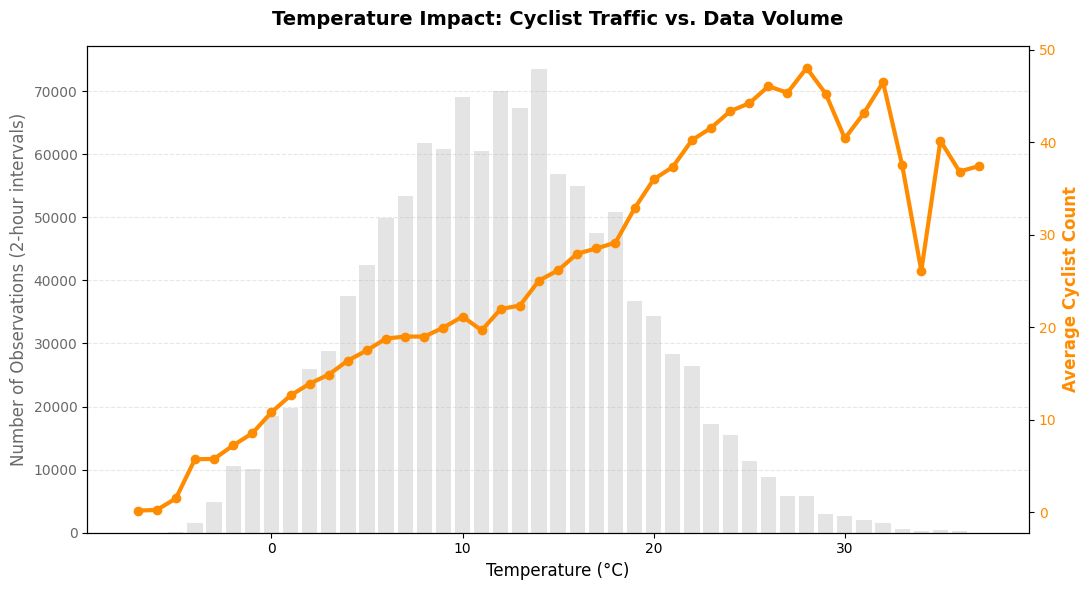

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. PREPARE THE DATA
# ==========================================
# Create a copy to avoid warnings
temp_trend = prediction_data.copy()

# Round the temperature to the nearest whole number for clean grouping
temp_trend['temp_rounded'] = temp_trend['temperature_mean'].round()

# Group by the rounded temperature to calculate BOTH metrics at once
temp_summary = temp_trend.groupby('temp_rounded').agg(
    num_obs=('count_rescaled', 'count'),    # Counts how many 2-hour intervals occurred
    avg_traffic=('count_rescaled', 'mean')  # Calculates the average traffic
).reset_index()

# ==========================================
# 2. PLOT THE DUAL-AXIS CHART
# ==========================================
# Set up the main figure and the primary axis (Left Y-Axis)
fig, ax1 = plt.subplots(figsize=(11, 6))

# Plot the background bars for Number of Observations
ax1.bar(
    temp_summary['temp_rounded'], 
    temp_summary['num_obs'], 
    color='lightgray', 
    alpha=0.6, 
    label='Data Volume'
)
ax1.set_xlabel("Temperature (°C)", fontsize=12)
ax1.set_ylabel("Number of Observations (2-hour intervals)", color='dimgray', fontsize=12)
ax1.tick_params(axis='y', labelcolor='dimgray')

# Create the secondary axis (Right Y-Axis) sharing the same X-axis
ax2 = ax1.twinx()

# Plot the foreground line for Average Traffic
ax2.plot(
    temp_summary['temp_rounded'], 
    temp_summary['avg_traffic'], 
    color='darkorange', 
    linewidth=3, 
    marker='o', 
    label='Avg Cyclists'
)
ax2.set_ylabel("Average Cyclist Count", color='darkorange', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='darkorange')

# ==========================================
# 3. FORMATTING
# ==========================================
plt.title("Temperature Impact: Cyclist Traffic vs. Data Volume", pad=15, fontsize=14, fontweight='bold')

# Keep grid lines subtle and only on one axis to avoid a messy crosshatch pattern
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax2.grid(False)

# Ensure nothing gets cut off
fig.tight_layout()

# Display in the notebook
plt.show()

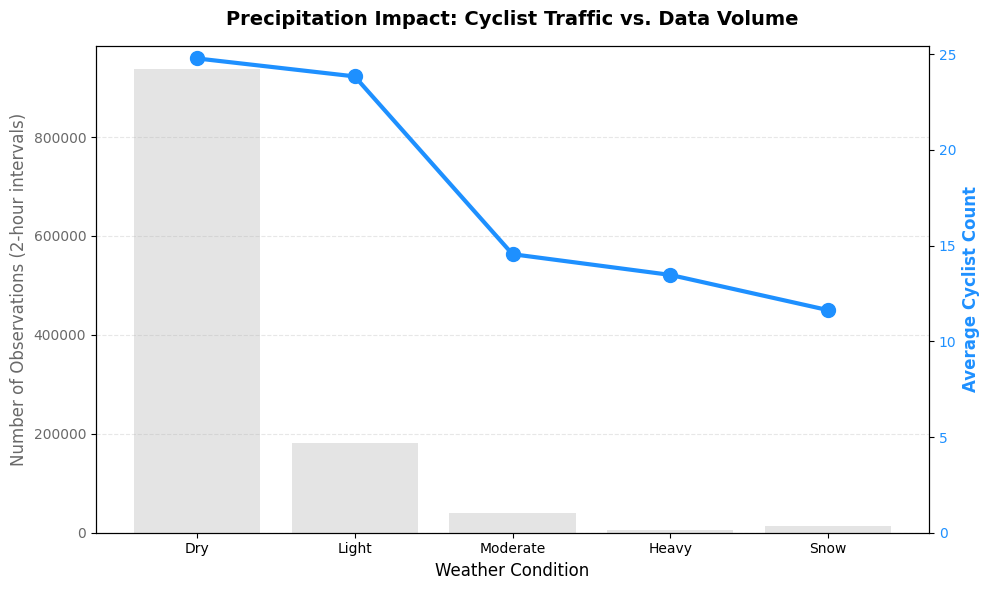

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. PREPARE THE DATA
# ==========================================
# Define the logical, increasing order of weather severity
precip_order = ['dry', 'light_precipitation', 'moderate_precipitation', 'heavy_precipitation', 'snow']

# Group by the category and calculate BOTH metrics
precip_summary = prediction_data.groupby('precipitation_category').agg(
    num_obs=('count_rescaled', 'count'),
    avg_traffic=('count_rescaled', 'mean')
)

# Reindex to enforce our logical order (Dry -> Light -> Moderate -> Heavy -> Snow)
precip_summary = precip_summary.reindex(precip_order).reset_index()

# Clean up the category names so they look beautiful on the X-axis
precip_summary['display_label'] = precip_summary['precipitation_category'].str.replace('_precipitation', '').str.title()

# ==========================================
# 2. PLOT THE DUAL-AXIS CHART
# ==========================================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the background bars for Number of Observations
ax1.bar(
    precip_summary['display_label'], 
    precip_summary['num_obs'], 
    color='lightgray', 
    alpha=0.6, 
    label='Data Volume'
)
ax1.set_xlabel("Weather Condition", fontsize=12)
ax1.set_ylabel("Number of Observations (2-hour intervals)", color='dimgray', fontsize=12)
ax1.tick_params(axis='y', labelcolor='dimgray')

# Create the secondary axis (Right Y-Axis)
ax2 = ax1.twinx()

# Plot the foreground line for Average Traffic
# Using a line with markers shows the "step-down" trend as weather gets worse
ax2.plot(
    precip_summary['display_label'], 
    precip_summary['avg_traffic'], 
    color='dodgerblue', 
    linewidth=3, 
    marker='o', 
    markersize=10,
    label='Avg Cyclists'
)
ax2.set_ylabel("Average Cyclist Count", color='dodgerblue', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='dodgerblue')

# ==========================================
# 3. FORMATTING
# ==========================================
plt.title("Precipitation Impact: Cyclist Traffic vs. Data Volume", pad=15, fontsize=14, fontweight='bold')

# Ensure the Y-axis for average traffic starts at 0 so the drop-off is visually accurate
ax2.set_ylim(bottom=0)

# Keep grid lines subtle
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax2.grid(False)

# Ensure everything fits perfectly
fig.tight_layout()

# Display in the notebook
plt.show()

       DATA CONTEXT: EVENT FREQUENCY      
       Condition  Total 2hr Intervals % of Total Year
      Normal Day              1125165           95.5%
Transport Strike                48400            4.1%
   Outdoor Music                 2136            0.2%
    Sports Event                 1604            0.1%
    Indoor Music                  288            0.0%



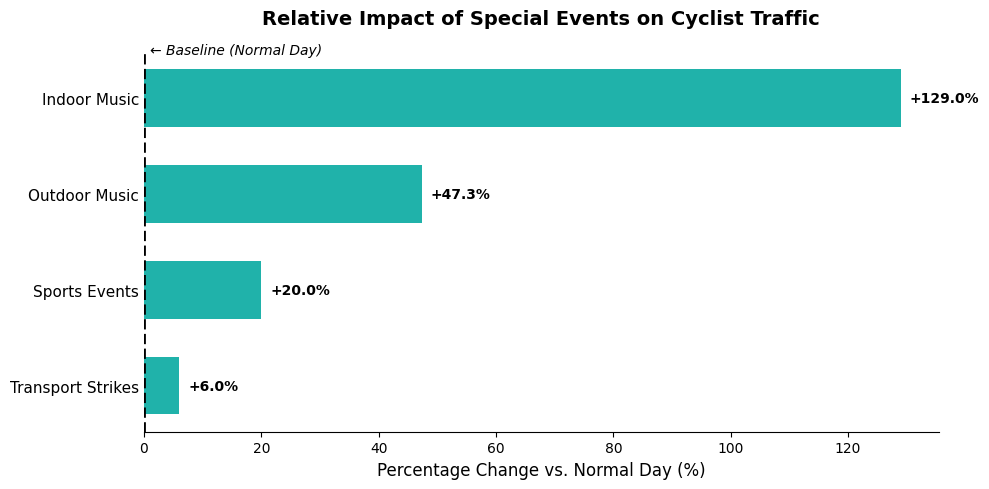

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CALCULATE THE BASELINE & FREQUENCY
# ==========================================
total_obs = len(prediction_data)

# Count how many intervals feature each event
sports_obs = prediction_data['is_sport_event'].sum()
outdoor_obs = prediction_data['is_outdoor_music'].sum()
indoor_obs = prediction_data['is_indoor_music'].sum()
strike_obs = prediction_data['is_strike'].sum()

# Define a "Normal Day" mask (No events). 
# Notice we are using PARENTHESES () here so Pandas reads it correctly!
baseline_mask = (
    (prediction_data['is_sport_event'] == 0) & 
    (prediction_data['is_outdoor_music'] == 0) & 
    (prediction_data['is_indoor_music'] == 0) &
    (prediction_data['is_strike'] == 0) 
)
normal_obs = baseline_mask.sum()

# Calculate the average cyclist traffic for each scenario
baseline_avg = prediction_data[baseline_mask]['count_rescaled'].mean()
sports_avg = prediction_data[prediction_data['is_sport_event'] == 1]['count_rescaled'].mean()
outdoor_avg = prediction_data[prediction_data['is_outdoor_music'] == 1]['count_rescaled'].mean()
indoor_avg = prediction_data[prediction_data['is_indoor_music'] == 1]['count_rescaled'].mean()
strike_avg = prediction_data[prediction_data['is_strike'] == 1]['count_rescaled'].mean()

# ==========================================
# 2. BUILD AND PRINT THE SUMMARY TABLE
# ==========================================
summary_table = pd.DataFrame({
    "Condition": ["Normal Day", "Sports Event", "Outdoor Music", "Indoor Music", "Transport Strike"],
    "Total 2hr Intervals": [normal_obs, sports_obs, outdoor_obs, indoor_obs, strike_obs],
})

# Calculate the percentage of the year this event takes up
summary_table["% of Total Year"] = (summary_table["Total 2hr Intervals"] / total_obs) * 100
summary_table["% of Total Year"] = summary_table["% of Total Year"].map("{:.1f}%".format)
summary_table = summary_table.sort_values("Total 2hr Intervals", ascending=False)

# Print the table to the VS Code terminal/output
print("==========================================")
print("       DATA CONTEXT: EVENT FREQUENCY      ")
print("==========================================")
print(summary_table.to_string(index=False))
print("==========================================\n")

# ==========================================
# 3. CALCULATE PERCENTAGE CHANGE (LIFT)
# ==========================================
def calc_lift(event_avg, base_avg):
    # Safety check: If an event has 0 observations, prevent a math error
    if pd.isna(event_avg) or pd.isna(base_avg) or base_avg == 0:
        return 0
    return ((event_avg - base_avg) / base_avg) * 100

impact_data = pd.DataFrame({
    'Event Type': ['Sports Events', 'Outdoor Music', 'Indoor Music', 'Transport Strikes'],
    'Impact (%)': [
        calc_lift(sports_avg, baseline_avg),
        calc_lift(outdoor_avg, baseline_avg),
        calc_lift(indoor_avg, baseline_avg),
        calc_lift(strike_avg, baseline_avg)
    ]
})

# Sort values so the chart flows from biggest drop to biggest spike
impact_data = impact_data.sort_values('Impact (%)')
colors = ['crimson' if x < 0 else 'lightseagreen' for x in impact_data['Impact (%)']]

# ==========================================
# 4. PLOT THE DIVERGING BAR CHART
# ==========================================
fig, ax = plt.subplots(figsize=(10, 5))

# Plot horizontal bars
bars = ax.barh(impact_data['Event Type'], impact_data['Impact (%)'], color=colors, height=0.6)

# Add the "Baseline" vertical line at 0%
ax.axvline(0, color='black', linewidth=2, linestyle='--')
ax.text(1, len(impact_data)-0.5, '← Baseline (Normal Day)', va='center', fontstyle='italic', fontsize=10)

# Formatting
ax.set_title("Relative Impact of Special Events on Cyclist Traffic", pad=20, fontsize=14, fontweight='bold')
ax.set_xlabel("Percentage Change vs. Normal Day (%)", fontsize=12)

# Clean up borders
sns.despine(left=True)
ax.tick_params(axis='y', length=0, labelsize=11)

# Add the exact percentage text to the end of each bar
for bar in bars:
    width = bar.get_width()
    label_x_pos = width + 1.5 if width > 0 else width - 1.5
    ha = 'left' if width > 0 else 'right'
    ax.text(
        label_x_pos, 
        bar.get_y() + bar.get_height() / 2, 
        f'{width:+.1f}%', 
        va='center', 
        ha=ha, 
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.show()

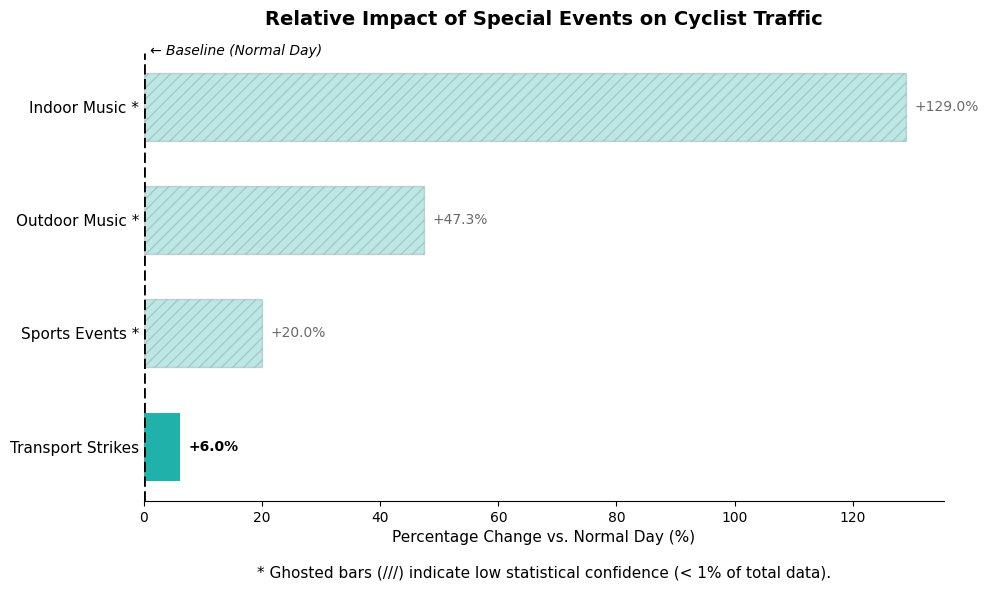

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CALCULATE THE BASELINE & FREQUENCY
# ==========================================
total_obs = len(prediction_data)

sports_obs = prediction_data['is_sport_event'].sum()
outdoor_obs = prediction_data['is_outdoor_music'].sum()
indoor_obs = prediction_data['is_indoor_music'].sum()
strike_obs = prediction_data['is_strike'].sum()

# PARENTHESES () to ensure a valid Pandas mask!
baseline_mask = (
    (prediction_data['is_sport_event'] == 0) & 
    (prediction_data['is_outdoor_music'] == 0) & 
    (prediction_data['is_indoor_music'] == 0) &
    (prediction_data['is_strike'] == 0) 
)
normal_obs = baseline_mask.sum()

baseline_avg = prediction_data[baseline_mask]['count_rescaled'].mean()
sports_avg = prediction_data[prediction_data['is_sport_event'] == 1]['count_rescaled'].mean()
outdoor_avg = prediction_data[prediction_data['is_outdoor_music'] == 1]['count_rescaled'].mean()
indoor_avg = prediction_data[prediction_data['is_indoor_music'] == 1]['count_rescaled'].mean()
strike_avg = prediction_data[prediction_data['is_strike'] == 1]['count_rescaled'].mean()

# ==========================================
# 2. CALCULATE LIFT & MERGE FREQUENCY
# ==========================================
def calc_lift(event_avg, base_avg):
    if pd.isna(event_avg) or pd.isna(base_avg) or base_avg == 0:
        return 0
    return ((event_avg - base_avg) / base_avg) * 100

impact_data = pd.DataFrame({
    'Event Type': ['Sports Events', 'Outdoor Music', 'Indoor Music', 'Transport Strikes'],
    'Observations': [sports_obs, outdoor_obs, indoor_obs, strike_obs],
    'Impact (%)': [
        calc_lift(sports_avg, baseline_avg),
        calc_lift(outdoor_avg, baseline_avg),
        calc_lift(indoor_avg, baseline_avg),
        calc_lift(strike_avg, baseline_avg)
    ]
})

# Calculate the % of the year for the threshold logic
impact_data['% of Year'] = (impact_data['Observations'] / total_obs) * 100

# Sort from biggest drop to biggest spike
impact_data = impact_data.sort_values('Impact (%)')

# Base colors (will be modified by the ghosting logic)
colors = ['crimson' if x < 0 else 'lightseagreen' for x in impact_data['Impact (%)']]

# ==========================================
# 3. PLOT WITH "GHOST CONFIDENCE"
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

# Plot all bars first
bars = ax.barh(impact_data['Event Type'], impact_data['Impact (%)'], color=colors, height=0.6)

new_y_labels = []

# Loop through each bar to apply the ghosting logic
for i, bar in enumerate(bars):
    pct = impact_data.iloc[i]['% of Year']
    event_name = impact_data.iloc[i]['Event Type']
    
    # LOW CONFIDENCE TRIGGER (< 1% of data)
    if pct < 1.0:
        bar.set_alpha(0.3)               # Make it highly transparent
        bar.set_hatch('///')             # Add warning stripes
        bar.set_edgecolor('gray')        # Outline it so the stripes show up
        new_y_labels.append(f"{event_name} *") # Add asterisk to the label
    else:
        new_y_labels.append(event_name)

# Apply the new labels with asterisks
ax.set_yticks(range(len(new_y_labels)))
ax.set_yticklabels(new_y_labels)

# Add the "Baseline" vertical line at 0%
ax.axvline(0, color='black', linewidth=2, linestyle='--')
ax.text(1, len(impact_data)-0.5, '← Baseline (Normal Day)', va='center', fontstyle='italic', fontsize=10)

# ==========================================
# 4. FORMATTING & DISCLAIMER
# ==========================================
ax.set_title("Relative Impact of Special Events on Cyclist Traffic", pad=20, fontsize=14, fontweight='bold')

# The disclaimer is baked right into the X-axis label!
ax.set_xlabel("Percentage Change vs. Normal Day (%)\n\n* Ghosted bars (///) indicate low statistical confidence (< 1% of total data).", 
              fontsize=11, color='black')

sns.despine(left=True)
ax.tick_params(axis='y', length=0, labelsize=11)

# Add exact percentage text
for i, bar in enumerate(bars):
    width = bar.get_width()
    label_x_pos = width + 1.5 if width > 0 else width - 1.5
    ha = 'left' if width > 0 else 'right'
    
    # If ghosted, make the text gray so it doesn't pop too much
    text_color = 'dimgray' if impact_data.iloc[i]['% of Year'] < 1.0 else 'black'
    font_weight = 'normal' if impact_data.iloc[i]['% of Year'] < 1.0 else 'bold'
    
    ax.text(
        label_x_pos, 
        bar.get_y() + bar.get_height() / 2, 
        f'{width:+.1f}%', 
        va='center', 
        ha=ha, 
        fontweight=font_weight,
        color=text_color
    )

plt.tight_layout()
plt.show()

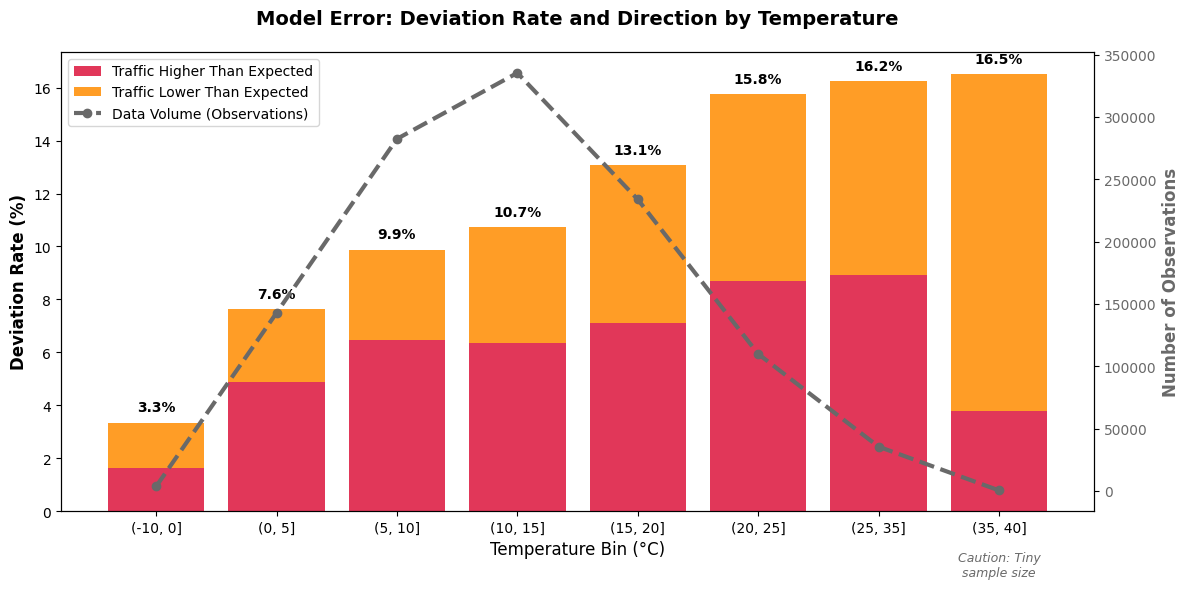

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. RECREATE THE DATA
# ==========================================
data = {
    'temperature_bin': ['(-10, 0]', '(0, 5]', '(5, 10]', '(10, 15]', '(15, 20]', '(20, 25]', '(25, 35]', '(35, 40]'],
    'observations': [3650, 142950, 282583, 335558, 234006, 109994, 35534, 448],
    'Higher than expected': [0.016163, 0.048681, 0.064763, 0.063718, 0.071131, 0.086859, 0.089098, 0.037946],
    'Lower than expected': [0.017314, 0.027758, 0.034029, 0.043486, 0.059541, 0.070731, 0.073226, 0.127232]
}
df = pd.DataFrame(data)

# Convert rates to percentages for better readability (e.g., 0.05 -> 5.0%)
df['Higher (%)'] = df['Higher than expected'] * 100
df['Lower (%)'] = df['Lower than expected'] * 100
df['Total Deviation (%)'] = df['Higher (%)'] + df['Lower (%)']

# ==========================================
# 2. PLOT THE DUAL-AXIS CHART
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot the stacked bars (Deviation Direction & Total Rate)
# 1st Bar: Higher than expected
ax1.bar(df['temperature_bin'], df['Higher (%)'], 
        color='crimson', label='Traffic Higher Than Expected', alpha=0.85)

# 2nd Bar: Lower than expected (Stacked on top of Higher)
ax1.bar(df['temperature_bin'], df['Lower (%)'], bottom=df['Higher (%)'], 
        color='darkorange', label='Traffic Lower Than Expected', alpha=0.85)

ax1.set_xlabel("Temperature Bin (°C)", fontsize=12)
ax1.set_ylabel("Deviation Rate (%)", fontsize=12, fontweight='bold')
ax1.tick_params(axis='y')

# Create the secondary axis for Observations (Data Volume)
ax2 = ax1.twinx()
ax2.plot(df['temperature_bin'], df['observations'], 
         color='dimgray', linewidth=3, marker='o', linestyle='--', label='Data Volume (Observations)')

ax2.set_ylabel("Number of Observations", color='dimgray', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='dimgray')

# ==========================================
# 3. FORMATTING AND ANNOTATIONS
# ==========================================
ax1.set_title("Model Error: Deviation Rate and Direction by Temperature", pad=20, fontsize=14, fontweight='bold')

# Combine legends from both axes into one clean box
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# Add the exact total deviation percentage to the top of each stacked bar
for i in range(len(df)):
    total_pct = df['Total Deviation (%)'][i]
    ax1.text(i, total_pct + 0.3, f"{total_pct:.1f}%", ha='center', va='bottom', fontweight='bold', fontsize=10)

# Optional: Add a warning note about the extreme right edge
ax1.text(7, -1.5, "Caution: Tiny\nsample size", ha='center', va='top', color='dimgray', fontsize=9, fontstyle='italic')

plt.tight_layout()
plt.show()